In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os

In [2]:
api_token = os.getenv("HUGGINGFACE_API_KEY")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
    huggingfacehub_api_token=api_token,
)

chat_model = ChatHuggingFace(llm=llm)

/home/sangam/agentic_ai/agentic_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
class ChatLLM(TypedDict):
    question: str
    answer: str

In [10]:
def llmcall(state: ChatLLM) -> ChatLLM:
    question = state['question']
    answer = chat_model.invoke(question).content
    state['answer'] = answer
    return state

In [13]:
graph = StateGraph(ChatLLM)

#add node
graph.add_node("llm", llmcall)

#add edges
graph.add_edge(START, "llm")
graph.add_edge("llm", END)

#compile graph
workflow = graph.compile()

In [15]:
initial_state = {'question': 'What is the capital of Nepal?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

The capital of Nepal is Kathmandu.


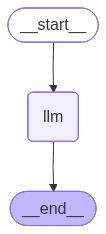

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())